# Sprint 3: From Market Data to Market Intelligence

**GeoRAD Emerging Spatial Professionals Mentorship Program · Week 4**

This notebook helps you:

1. **Map your five towns** (spatial orientation first)
2. Upload and review your **Sprint 2 market dataset**
3. Analyze prices and produce an **Indicative Market Level** per town
4. Chart market differences
5. Put the market signal **back on the map**
6. Experiment (mean vs median, unusual values, extra towns)

You do **not** need to write the analysis from scratch. Focus on connecting your data, running the workflow, inspecting results, and thinking like a spatial analyst.

> This is an indicative asking-price analysis, not a formal property valuation.


## 0. Install packages

Run once per Colab session.


In [1]:
# Tables, charts, and a simple interactive map
%pip install -q pandas matplotlib geopandas folium mapclassify


## 1. Map your towns (spatial orientation)

Start with the map.

Upload the **same towns GeoJSON** you used in Sprint 1 / Sprint 2 (five towns; name field usually `ward`).

This step is about **where** the towns are. After you load the market dataset, we will check that town names match, then colour the map by market level later.


In [5]:
from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt

try:
    from google.colab import files  # type: ignore
    print("Upload your towns GeoJSON (Sprint 1 selected towns).")
    geo_uploaded = files.upload()
    GEOJSON_PATH = next(iter(geo_uploaded))
except Exception:
    GEOJSON_PATH = "sample_towns.geojson"

gdf = gpd.read_file(GEOJSON_PATH)
print(f"Loaded GeoJSON: {GEOJSON_PATH}")
print(f"Features: {len(gdf)} | CRS: {gdf.crs}")
print(f"Geometry types: {Counter(gdf.geometry.geom_type)}")
print(f"Property columns: {list(gdf.columns)}")

# Detect town-name field (prefer ward, matching Sprint 2 notebook)
PREFERRED_NAME_FIELDS = ["ward", "town", "town_name", "name", "NAME", "Town"]
TOWN_NAME_FIELD = "wardname"  # Override if needed, e.g. TOWN_NAME_FIELD = "ward"

if TOWN_NAME_FIELD is None:
    for field in PREFERRED_NAME_FIELDS:
        if (
            field in gdf.columns
            and gdf[field].notna().all()
            and (gdf[field].astype(str).str.strip() != "").all()
        ):
            TOWN_NAME_FIELD = field
            break

if TOWN_NAME_FIELD is None:
    raise ValueError(
        "Could not detect a town-name field. Set TOWN_NAME_FIELD manually. "
        f"Columns: {list(gdf.columns)}"
    )

print(f"Using town-name field: {TOWN_NAME_FIELD}")
gdf = gdf.copy()
gdf["Town"] = gdf[TOWN_NAME_FIELD].astype(str).str.strip()
print("Towns:", sorted(gdf["Town"].unique().tolist()))


def folium_safe_gdf(frame: gpd.GeoDataFrame, keep_cols: list) -> gpd.GeoDataFrame:
    """Keep only map fields and stringify values Folium cannot JSON-encode (e.g. Timestamps)."""
    cols = [c for c in keep_cols if c in frame.columns]
    out = frame[cols + ["geometry"]].copy()
    for col in cols:
        if pd.api.types.is_datetime64_any_dtype(out[col]):
            out[col] = out[col].astype(str)
        else:
            out[col] = out[col].map(
                lambda v: None
                if v is None or (isinstance(v, float) and np.isnan(v))
                else str(v)
                if not isinstance(v, (str, int, float, bool))
                else v
            )
    return out


# WGS84 for Folium
towns_wgs = gdf.to_crs(epsg=4326) if gdf.crs and gdf.crs.to_epsg() != 4326 else gdf.copy()
if towns_wgs.crs is None:
    towns_wgs = towns_wgs.set_crs(epsg=4326)

# Only pass Town (+ geometry). Extra GeoJSON properties often include dates that break folium.save().
towns_map_gdf = folium_safe_gdf(towns_wgs, ["Town"])

minx, miny, maxx, maxy = towns_map_gdf.total_bounds
center = [(miny + maxy) / 2, (minx + maxx) / 2]

# Basemap: OSM often 403s in Colab; Carto may want an API key.
# Esri World Street Map works for classroom demos without a key.
BASEMAP_TILES = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/"
    "World_Street_Map/MapServer/tile/{z}/{y}/{x}"
)
BASEMAP_ATTR = "Tiles &copy; Esri"

towns_map = folium.Map(
    location=center,
    zoom_start=11,
    tiles=BASEMAP_TILES,
    attr=BASEMAP_ATTR,
)
guide_types = set(towns_map_gdf.geometry.geom_type)

if guide_types <= {"Point", "MultiPoint"}:
    for _, row in towns_map_gdf.iterrows():
        geom = row.geometry
        pts = list(geom.geoms) if geom.geom_type == "MultiPoint" else [geom]
        for pt in pts:
            folium.CircleMarker(
                location=[pt.y, pt.x],
                radius=9,
                color="#1f4e79",
                fill=True,
                fill_color="#4a90c6",
                fill_opacity=0.85,
                popup=folium.Popup(f"<b>{row['Town']}</b>", max_width=240),
                tooltip=row["Town"],
            ).add_to(towns_map)
else:
    def style_town(_feature):
        return {
            "fillColor": "#4a90c6",
            "color": "#1f4e79",
            "weight": 1.5,
            "fillOpacity": 0.55,
        }

    folium.GeoJson(
        json.loads(towns_map_gdf.to_json()),
        style_function=style_town,
        tooltip=folium.GeoJsonTooltip(fields=["Town"]),
        popup=folium.GeoJsonPopup(fields=["Town"]),
    ).add_to(towns_map)

towns_map.fit_bounds([[miny, minx], [maxy, maxx]])

Path("sprint3_outputs").mkdir(exist_ok=True)
towns_map_path = Path("sprint3_outputs/towns_orientation_map.html")
towns_map.save(str(towns_map_path))
print(f"Saved orientation map: {towns_map_path}")
towns_map

Upload your towns GeoJSON (Sprint 1 selected towns).


Saving Igando_Ikotun.geojson to Igando_Ikotun (2).geojson
Loaded GeoJSON: Igando_Ikotun (2).geojson
Features: 5 | CRS: EPSG:4326
Geometry types: Counter({'MultiPolygon': 5})
Property columns: ['FID', 'globalid', 'uniq_id', 'timestamp', 'editor', 'wardname', 'wardcode', 'lganame', 'lgacode', 'statename', 'statecode', 'amapcode', 'status', 'source', 'urban', 'geometry']
Using town-name field: wardname
Towns: ['Abaranje / Okerube', 'Egan', 'Igando', 'Ikotun', 'Isheri-Olofin']
Saved orientation map: sprint3_outputs/towns_orientation_map.html


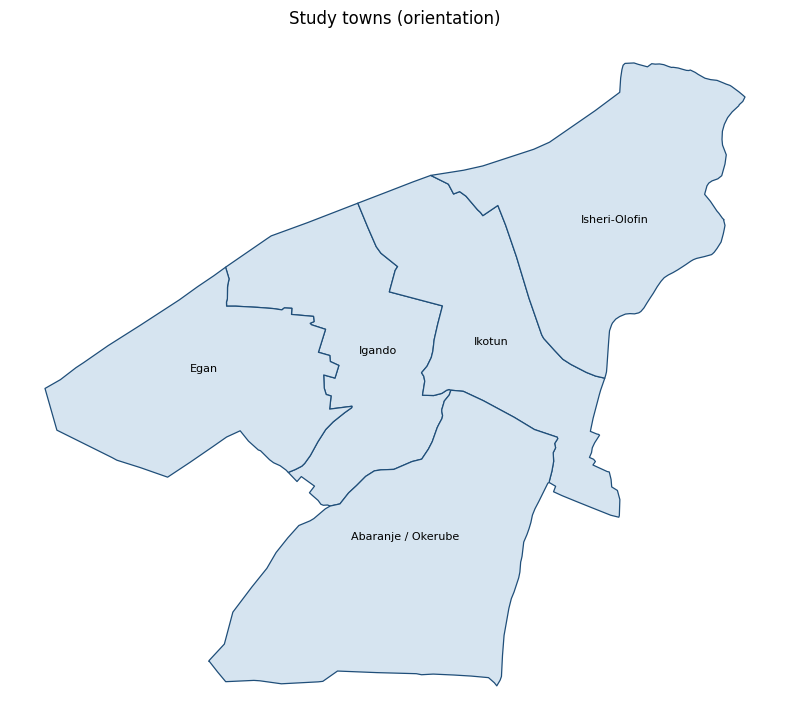

Saved: sprint3_outputs/towns_orientation_map.png


In [6]:
# Static overview of town locations (useful for README)
fig, ax = plt.subplots(figsize=(8, 8))
towns_wgs.plot(ax=ax, color="#d6e4f0", edgecolor="#1f4e79", linewidth=0.9)
for _, row in towns_wgs.iterrows():
    pt = row.geometry.representative_point() if row.geometry.geom_type != "Point" else row.geometry
    ax.annotate(row["Town"], xy=(pt.x, pt.y), fontsize=8, ha="center")
ax.set_title("Study towns (orientation)")
ax.set_axis_off()
plt.tight_layout()
orientation_png = Path("sprint3_outputs/towns_orientation_map.png")
fig.savefig(orientation_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {orientation_png}")


## 2. Upload your Sprint 2 market dataset

Upload the CSV or JSON you exported in Sprint 2.

**Minimum columns:**

| Field | Description |
| --- | --- |
| Town | Assigned town |
| Current Land Price/sqm | Price in ₦/sqm |
| Supporting Source | Evidence (optional for analysis, keep for audit) |
| Date Searched | Search date (optional for analysis) |

**Tip:** Sprint 2 usually gives **one price per town**. That is enough for an Indicative Market Level. The sample file may include extra rows for experimentation; if you only have one row per town, that is expected.


In [7]:
try:
    from google.colab import files  # type: ignore
    uploaded = files.upload()
    DATA_PATH = next(iter(uploaded))
except Exception:
    # Local fallback for facilitators testing outside Colab
    DATA_PATH = "sample_sprint2_market_data.csv"

path = Path(DATA_PATH)
suffix = path.suffix.lower()

if suffix == ".csv":
    raw_df = pd.read_csv(path)
elif suffix in {".json", ".geojson"}:
    raw_df = pd.read_json(path)
elif suffix in {".xlsx", ".xls"}:
    raw_df = pd.read_excel(path)
else:
    raise ValueError(f"Unsupported file type: {suffix}. Use CSV, JSON, or Excel.")

print(f"Loaded: {path.name}")
print(f"Rows: {len(raw_df)} | Columns: {list(raw_df.columns)}")
raw_df.head()


Saving market_dataset.csv to market_dataset.csv
Loaded: market_dataset.csv
Rows: 5 | Columns: ['Town', 'Current Land Price/sqm', 'Supporting Source', 'Date Searched']


,Town,Current Land Price/sqm,Supporting Source,Date Searched
0,Igando,85380naria/sqm,Property for sale!!! We are offering a plot of...,9/25/2026
1,Ikotun,140000naria/sqm,OWN A PIECE OF LAGOS PRESTIGE IN PG ESTATE ......,9/25/2026
2,Isheri-Olofin,196000naria/sqm,Distress Estate land for sale at Hotel Bus Sto...,9/25/2026
3,Abaranje / Okerube,60600naria/sqm,* *_DISTRESS One Plot of Land Directly Facing ...,9/25/2026
4,Egan,75000naria/sqm,"4+ Lands for Sale in Egan, Ikotun Igando, Lago...",9/25/2026


## 3. Confirm required columns and clean prices

We normalize column names, parse prices into numbers (₦/sqm), and flag missing or unusable values.

We also check that market-table town names match the GeoJSON towns from Section 1.


In [8]:
import re

# Flexible column aliases -> standard names
COLUMN_ALIASES = {
    "town": "Town",
    "town_name": "Town",
    "ward": "Town",
    "location": "Town",
    "current land price/sqm": "Current Land Price/sqm",
    "current_land_price_sqm": "Current Land Price/sqm",
    "price_sqm": "Current Land Price/sqm",
    "price/sqm": "Current Land Price/sqm",
    "land_price_sqm": "Current Land Price/sqm",
    "supporting source": "Supporting Source",
    "source": "Supporting Source",
    "date searched": "Date Searched",
    "date": "Date Searched",
}


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    rename = {}
    for col in out.columns:
        key = str(col).strip().lower()
        if key in COLUMN_ALIASES:
            rename[col] = COLUMN_ALIASES[key]
    out = out.rename(columns=rename)
    return out


def parse_price(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    if isinstance(value, (int, float)):
        return float(value)
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "n/a", "-", "null"}:
        return None
    # Keep digits and decimal point; strip currency symbols / commas / text
    cleaned = re.sub(r"[^0-9.]", "", text.replace(",", ""))
    if cleaned.count(".") > 1:
        # e.g. 850.000.000 -> keep last as decimal only if short; else drop dots as thousands
        parts = cleaned.split(".")
        cleaned = "".join(parts[:-1]) + "." + parts[-1] if len(parts[-1]) <= 2 else "".join(parts)
    try:
        return float(cleaned) if cleaned else None
    except ValueError:
        return None


market_df = normalize_columns(raw_df)

required = ["Town", "Current Land Price/sqm"]
missing_cols = [c for c in required if c not in market_df.columns]
if missing_cols:
    raise ValueError(
        "Missing required columns after rename: "
        + ", ".join(missing_cols)
        + f". Found: {list(market_df.columns)}"
    )

market_df["Town"] = market_df["Town"].astype(str).str.strip()
market_df["Price_sqm"] = market_df["Current Land Price/sqm"].map(parse_price)

qa = {
    "rows": len(market_df),
    "towns": market_df["Town"].nunique(dropna=True),
    "missing_town": int(market_df["Town"].isna().sum() + (market_df["Town"] == "").sum()),
    "missing_or_unparsed_price": int(market_df["Price_sqm"].isna().sum()),
    "price_min": market_df["Price_sqm"].min(skipna=True),
    "price_max": market_df["Price_sqm"].max(skipna=True),
    "price_median": market_df["Price_sqm"].median(skipna=True),
}
print("QA summary:")
for k, v in qa.items():
    print(f"  {k}: {v}")

print("\nTowns present:")
print(sorted(market_df["Town"].dropna().unique().tolist()))

clean_df = market_df.dropna(subset=["Town", "Price_sqm"]).copy()
clean_df = clean_df[clean_df["Town"] != ""]
print(f"\nUsable observations: {len(clean_df)}")

# Name match against GeoJSON from Section 1
market_towns = set(clean_df["Town"].unique())
geo_towns = set(gdf["Town"].unique())
print("\nName match (market table vs GeoJSON):")
print("  Matched:", sorted(market_towns & geo_towns))
print("  In market table but not in GeoJSON:", sorted(market_towns - geo_towns))
print("  In GeoJSON but not in market table:", sorted(geo_towns - market_towns))

clean_df[["Town", "Price_sqm"]].head(10)


QA summary:
  rows: 5
  towns: 5
  missing_town: 0
  missing_or_unparsed_price: 0
  price_min: 60600.0
  price_max: 196000.0
  price_median: 85380.0

Towns present:
['Abaranje / Okerube', 'Egan', 'Igando', 'Ikotun', 'Isheri-Olofin']

Usable observations: 5

Name match (market table vs GeoJSON):
  Matched: ['Abaranje / Okerube', 'Egan', 'Igando', 'Ikotun', 'Isheri-Olofin']
  In market table but not in GeoJSON: []
  In GeoJSON but not in market table: []


,Town,Price_sqm
0,Igando,85380.0
1,Ikotun,140000.0
2,Isheri-Olofin,196000.0
3,Abaranje / Okerube,60600.0
4,Egan,75000.0


## 4. Analyze the market data and generate Indicative Market Levels

Sprint 2 typically provides **one asking-price signal per town**. From that, we produce an **Indicative Market Level** (a single representative ₦/sqm value for the web product).

We do **not** invent a Current Market Range from a single observation. A meaningful range needs multiple listings per town.

| Output | Rule |
| --- | --- |
| **Indicative Market Level** | Median of usable prices for that town. If n = 1 (typical Sprint 2), the indicative level is that price. |

The market-intelligence table keeps **every column from your Sprint 2 input** and adds the new analysis fields.

**Do not simply accept the output.** Ask whether the result reasonably represents what the data is showing.


In [9]:
def format_naira(value: float) -> str:
    return f"₦{value:,.0f}"


# Overall (all towns together)
overall = clean_df["Price_sqm"]
print("Overall price summary (₦/sqm):")
print(overall.describe())
print(f"\nTowns with data: {clean_df['Town'].nunique()}")
print(f"Observations per town:\n{clean_df.groupby('Town').size().to_string()}")

# Per-town stats (indicative = median; equals the Sprint 2 price when n = 1)
town_stats = (
    clean_df.groupby("Town")["Price_sqm"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
    .reset_index()
)
town_stats["mean_vs_median"] = town_stats["mean"] - town_stats["median"]
print("\nPer-town stats:")
print(town_stats.to_string(index=False))

# Town-level indicative fields (one row per town)
town_levels = (
    clean_df.groupby("Town", as_index=False)
    .agg(
        n=("Price_sqm", "count"),
        Indicative=("Price_sqm", "median"),
        Mean=("Price_sqm", "mean"),
    )
)
town_levels["Indicative Market Level"] = town_levels["Indicative"].map(
    lambda v: f"{format_naira(float(v))} / sqm"
)

# Keep every Sprint 2 input column, then append the new analysis fields
new_cols = ["n", "Indicative", "Mean", "Indicative Market Level"]
intelligence_df = clean_df.merge(town_levels[["Town"] + new_cols], on="Town", how="left")
intelligence_df = intelligence_df.sort_values(
    ["Indicative", "Town"], ascending=[False, True]
).reset_index(drop=True)

print("\nMarket intelligence (input columns + new fields):")
print(
    "Note: with one Sprint 2 price per town, Indicative = that price. "
    "No Current Market Range is produced."
)
print(f"Columns: {list(intelligence_df.columns)}")
intelligence_df


Overall price summary (₦/sqm):
count         5.000000
mean     111396.000000
std       56030.706581
min       60600.000000
25%       75000.000000
50%       85380.000000
75%      140000.000000
max      196000.000000
Name: Price_sqm, dtype: float64

Towns with data: 5
Observations per town:
Town
Abaranje / Okerube    1
Egan                  1
Igando                1
Ikotun                1
Isheri-Olofin         1

Per-town stats:
              Town  n     mean   median      min      max  mean_vs_median
Abaranje / Okerube  1  60600.0  60600.0  60600.0  60600.0             0.0
              Egan  1  75000.0  75000.0  75000.0  75000.0             0.0
            Igando  1  85380.0  85380.0  85380.0  85380.0             0.0
            Ikotun  1 140000.0 140000.0 140000.0 140000.0             0.0
     Isheri-Olofin  1 196000.0 196000.0 196000.0 196000.0             0.0

Market intelligence (input columns + new fields):
Note: with one Sprint 2 price per town, Indicative = that price. No Curre

,Town,Current Land Price/sqm,Supporting Source,Date Searched,Price_sqm,n,Indicative,Mean,Indicative Market Level
0,Isheri-Olofin,196000naria/sqm,Distress Estate land for sale at Hotel Bus Sto...,9/25/2026,196000.0,1,196000.0,196000.0,"₦196,000 / sqm"
1,Ikotun,140000naria/sqm,OWN A PIECE OF LAGOS PRESTIGE IN PG ESTATE ......,9/25/2026,140000.0,1,140000.0,140000.0,"₦140,000 / sqm"
2,Igando,85380naria/sqm,Property for sale!!! We are offering a plot of...,9/25/2026,85380.0,1,85380.0,85380.0,"₦85,380 / sqm"
3,Egan,75000naria/sqm,"4+ Lands for Sale in Egan, Ikotun Igando, Lago...",9/25/2026,75000.0,1,75000.0,75000.0,"₦75,000 / sqm"
4,Abaranje / Okerube,60600naria/sqm,* *_DISTRESS One Plot of Land Directly Facing ...,9/25/2026,60600.0,1,60600.0,60600.0,"₦60,600 / sqm"


## 5. Compare your five towns

Look across towns:

- Which have similar market levels?
- Which appear different?
- What spatial or local factors might explain differences?
- Does anything surprise you?

Do not force a conclusion simply because the numbers differ.


In [10]:
# One row per town for comparison (from town_levels)
compare = town_levels[["Town", "Indicative", "n", "Mean"]].copy()
compare["Mean_vs_Median"] = compare["Mean"] - compare["Indicative"]
compare = compare.sort_values("Indicative", ascending=False)

print("Sorted by indicative market level (high to low):")
print(compare.to_string(index=False))

print("\nQuick prompts:")
if len(compare) >= 2:
    print(f"  Highest: {compare.iloc[0]['Town']} ({format_naira(compare.iloc[0]['Indicative'])}/sqm)")
    print(f"  Lowest:  {compare.iloc[-1]['Town']} ({format_naira(compare.iloc[-1]['Indicative'])}/sqm)")
    gap = compare.iloc[0]["Indicative"] - compare.iloc[-1]["Indicative"]
    print(f"  Gap (highest - lowest): {format_naira(gap)} / sqm")


Sorted by indicative market level (high to low):
              Town  Indicative  n     Mean  Mean_vs_Median
     Isheri-Olofin    196000.0  1 196000.0             0.0
            Ikotun    140000.0  1 140000.0             0.0
            Igando     85380.0  1  85380.0             0.0
              Egan     75000.0  1  75000.0             0.0
Abaranje / Okerube     60600.0  1  60600.0             0.0

Quick prompts:
  Highest: Isheri-Olofin (₦196,000/sqm)
  Lowest:  Abaranje / Okerube (₦60,600/sqm)
  Gap (highest - lowest): ₦135,400 / sqm


## 6. Market visualization (charts)

At least one chart is required for submission. Below: a bar chart of Indicative Market Levels across your five towns.


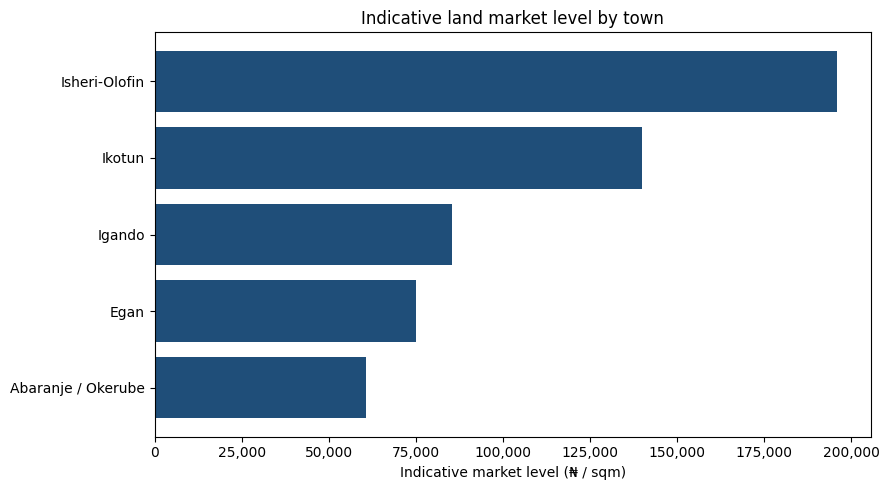

Saved: sprint3_outputs/market_levels_bar.png


In [11]:
# Bar chart: indicative market level by town
plot_df = town_levels.sort_values("Indicative")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["Town"], plot_df["Indicative"], color="#1f4e79")
ax.set_xlabel("Indicative market level (₦ / sqm)")
ax.set_title("Indicative land market level by town")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
Path("sprint3_outputs").mkdir(exist_ok=True)
fig.savefig("sprint3_outputs/market_levels_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sprint3_outputs/market_levels_bar.png")


## 7. Put the market signal on the map

Join your **Indicative Market Level** onto the towns GeoJSON from Section 1 and draw the map.

Town names must still match. If something is unmatched, fix spelling before trusting the map.


Towns matched to market intelligence: 5 / 5
In market table but not in GeoJSON: []
              Town Indicative Market Level
            Igando           ₦85,380 / sqm
            Ikotun          ₦140,000 / sqm
     Isheri-Olofin          ₦196,000 / sqm
Abaranje / Okerube           ₦60,600 / sqm
              Egan           ₦75,000 / sqm
Saved interactive market map: sprint3_outputs/towns_market_map.html


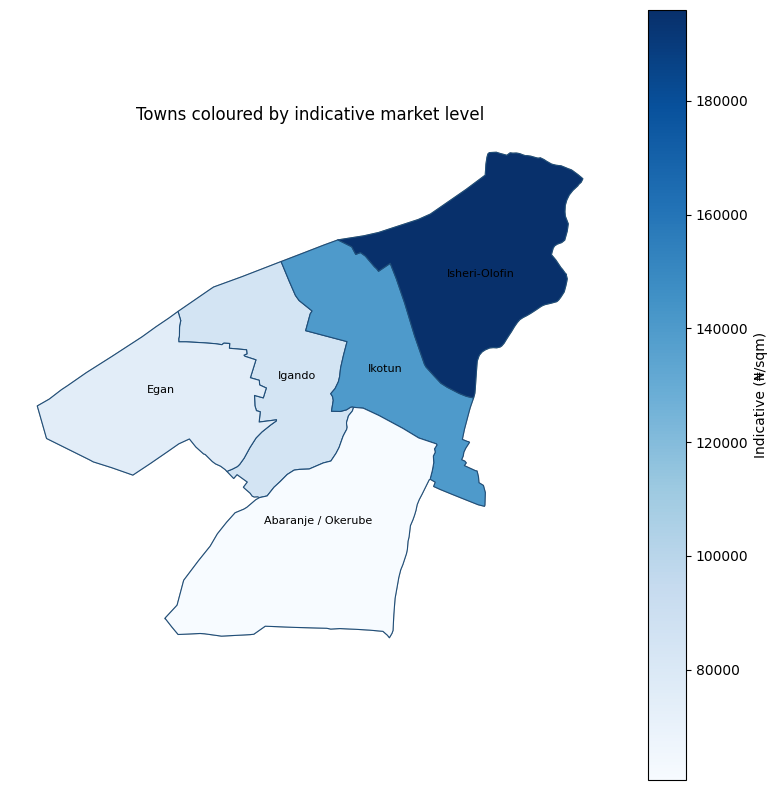

Saved: sprint3_outputs/towns_market_map.png


In [12]:
from branca.colormap import LinearColormap

# --- Join indicative levels onto GeoJSON ---
join_cols = [
    "Town",
    "Indicative Market Level",
    "Indicative",
    "n",
]
# One row per town for the map join
mapped = gdf.merge(town_levels[join_cols], on="Town", how="left")

matched = mapped["Indicative"].notna().sum()
print(f"Towns matched to market intelligence: {matched} / {len(mapped)}")
unmatched = mapped.loc[mapped["Indicative"].isna(), "Town"].tolist()
if unmatched:
    print("Unmatched GeoJSON towns (check spelling):", unmatched)

market_only = set(town_levels["Town"])
geo_only = set(mapped["Town"])
print("In market table but not in GeoJSON:", sorted(market_only - geo_only))
print(mapped[["Town", "Indicative Market Level"]].to_string(index=False))

# --- Interactive map ---
mapped_wgs = mapped.to_crs(epsg=4326) if mapped.crs and mapped.crs.to_epsg() != 4326 else mapped.copy()
if mapped_wgs.crs is None:
    mapped_wgs = mapped_wgs.set_crs(epsg=4326)

# Drop non-JSON-safe property columns before Folium (dates, etc.)
map_keep = [
    "Town",
    "Indicative Market Level",
    "Indicative",
    "n",
]
market_map_gdf = folium_safe_gdf(mapped_wgs, map_keep)
# Keep Indicative numeric for colouring
if "Indicative" in mapped_wgs.columns:
    market_map_gdf["Indicative"] = pd.to_numeric(mapped_wgs["Indicative"], errors="coerce")
if "n" in mapped_wgs.columns:
    market_map_gdf["n"] = pd.to_numeric(mapped_wgs["n"], errors="coerce")

minx, miny, maxx, maxy = market_map_gdf.total_bounds
center = [(miny + maxy) / 2, (minx + maxx) / 2]

m = folium.Map(
    location=center,
    zoom_start=11,
    tiles=BASEMAP_TILES,
    attr=BASEMAP_ATTR,
)

priced = market_map_gdf.dropna(subset=["Indicative"])
if len(priced) == 0:
    print("No matched prices to map. Fix town-name joins first.")
else:
    vmin = float(priced["Indicative"].min())
    vmax = float(priced["Indicative"].max())
    if vmin == vmax:
        vmax = vmin + 1
    colormap = LinearColormap(
        colors=["#f7fbff", "#6baed6", "#08306b"],
        vmin=vmin,
        vmax=vmax,
        caption="Indicative market level (₦ / sqm)",
    )

    def style_feature(feature):
        val = feature["properties"].get("Indicative")
        if val is None:
            return {"fillColor": "#cccccc", "color": "#666666", "weight": 1, "fillOpacity": 0.4}
        return {
            "fillColor": colormap(val),
            "color": "#1f4e79",
            "weight": 1.5,
            "fillOpacity": 0.65,
        }

    geom_types = set(priced.geometry.geom_type)
    if geom_types <= {"Point", "MultiPoint"}:
        for _, row in priced.iterrows():
            geom = row.geometry
            pts = list(geom.geoms) if geom.geom_type == "MultiPoint" else [geom]
            for pt in pts:
                html = (
                    f"<b>{row['Town']}</b><br>"
                    f"Indicative: {row['Indicative Market Level']}<br>"
                    f"n={row['n']}"
                )
                folium.CircleMarker(
                    location=[pt.y, pt.x],
                    radius=10,
                    color="#1f4e79",
                    fill=True,
                    fill_color=colormap(row["Indicative"]),
                    fill_opacity=0.8,
                    popup=folium.Popup(html, max_width=280),
                    tooltip=row["Town"],
                ).add_to(m)
    else:
        folium.GeoJson(
            json.loads(priced.to_json()),
            style_function=style_feature,
            tooltip=folium.GeoJsonTooltip(
                fields=["Town", "Indicative Market Level"]
            ),
            popup=folium.GeoJsonPopup(
                fields=["Town", "Indicative Market Level", "n"]
            ),
        ).add_to(m)

    colormap.add_to(m)
    m.fit_bounds([[miny, minx], [maxy, maxx]])

map_path = Path("sprint3_outputs/towns_market_map.html")
m.save(str(map_path))
print(f"Saved interactive market map: {map_path}")

# --- Static map (useful for README / submission image) ---
fig, ax = plt.subplots(figsize=(8, 8))
base = mapped_wgs.copy()
base.plot(ax=ax, color="#eeeeee", edgecolor="#999999", linewidth=0.8)

priced_plot = mapped_wgs.dropna(subset=["Indicative"])
if len(priced_plot):
    priced_plot.plot(
        ax=ax,
        column="Indicative",
        cmap="Blues",
        legend=True,
        edgecolor="#1f4e79",
        linewidth=0.8,
        legend_kwds={"label": "Indicative (₦/sqm)"},
    )
    for _, row in priced_plot.iterrows():
        pt = row.geometry.representative_point() if row.geometry.geom_type != "Point" else row.geometry
        ax.annotate(row["Town"], xy=(pt.x, pt.y), fontsize=8, ha="center")

ax.set_title("Towns coloured by indicative market level")
ax.set_axis_off()
plt.tight_layout()
static_path = Path("sprint3_outputs/towns_market_map.png")
fig.savefig(static_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {static_path}")

m


## 8. Export market intelligence + charts

Download these for your Sprint 3 submission:

1. Market intelligence table (CSV / JSON): **all Sprint 2 input columns** plus Indicative Market Level (and helper fields)
2. At least one chart (bar)
3. Optional: towns map (orientation and/or market-coloured HTML/PNG)


In [13]:
out_dir = Path("sprint3_outputs")
out_dir.mkdir(exist_ok=True)

# Full table: original Sprint 2 fields + new analysis fields
submission = intelligence_df.copy()
csv_path = out_dir / "market_intelligence.csv"
json_path = out_dir / "market_intelligence.json"

submission.to_csv(csv_path, index=False)
submission.to_json(json_path, orient="records", indent=2)

print("Wrote:")
for p in [csv_path, json_path]:
    print(f"  {p}")
print(f"Columns exported: {list(submission.columns)}")

try:
    from google.colab import files  # type: ignore
    files.download(str(csv_path))
    files.download(str(json_path))
    files.download("sprint3_outputs/market_levels_bar.png")
    if Path("sprint3_outputs/towns_market_map.png").exists():
        files.download("sprint3_outputs/towns_market_map.png")
except Exception:
    print("Not in Colab (or download skipped). Files are in sprint3_outputs/.")


Wrote:
  sprint3_outputs/market_intelligence.csv
  sprint3_outputs/market_intelligence.json
Columns exported: ['Town', 'Current Land Price/sqm', 'Supporting Source', 'Date Searched', 'Price_sqm', 'n', 'Indicative', 'Mean', 'Indicative Market Level']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Experiments (required: try at least one)

Ideas:

1. Compare mean vs median in the comparison table
2. Change one town's price and re-run Section 4
3. Add another town outside your study area and re-run from Section 2
4. Ask an AI tool to explain how the Indicative Market Level is calculated
5. Change chart colours or switch the map basemap

Record what you tried and what you observed in your README / reflection.


In [ ]:
# Experiment starter: mean vs median per town
exp = (
    clean_df.groupby("Town")["Price_sqm"]
    .agg(mean="mean", median="median", n="count")
    .assign(difference=lambda d: d["mean"] - d["median"])
    .sort_values("difference", key=abs, ascending=False)
)
print("Where mean and median diverge most (with n = 1 they are identical):")
exp


Where mean and median diverge most (with n = 1 they are identical):


,mean,median,n,difference
Town,,,,
Idiya,106688.0,106688.0,1,0.0
Ikereku 1,30000.0,30000.0,1,0.0
Ikereku 2,27000.0,27000.0,1,0.0
Imala,1359.0,1359.0,1,0.0
Olorunda,618.0,618.0,1,0.0
